## EDA CUSTOMERS Purchase Behavior Analysis 

Purchase behavior

    - Total_Purchases (X)

    - Average_Order_Value

    - Days_Since_Last_Purchase
    
    - Discount_Usage_Rate

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [95]:
purchaseBehaviors_type_data = df[["Total_Purchases", "Average_Order_Value","Days_Since_Last_Purchase", "Discount_Usage_Rate"]]

In [96]:
stats = purchaseBehaviors_type_data.describe().T  # .T = transpose ให้อ่านง่ายขึ้น
stats["skewness"] = purchaseBehaviors_type_data.skew()
stats["kurtosis"] = purchaseBehaviors_type_data.kurt()
stats["outliers"] = 0
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,outliers
Total_Purchases,50000.0,13.116560,7.005246,0.00,8.00,12.00,17.00,128.700000,2.714766,25.934688,0
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.05,112.97,144.44,9666.379178,42.363862,1959.931679,0
Days_Since_Last_Purchase,50000.0,29.265300,28.866043,0.00,9.00,21.00,39.00,287.000000,2.090718,6.286718,0
Discount_Usage_Rate,49793.0,41.607486,20.246074,0.24,26.40,40.20,55.30,99.960000,0.334131,-0.428149,0


### 1. Total_Purchases

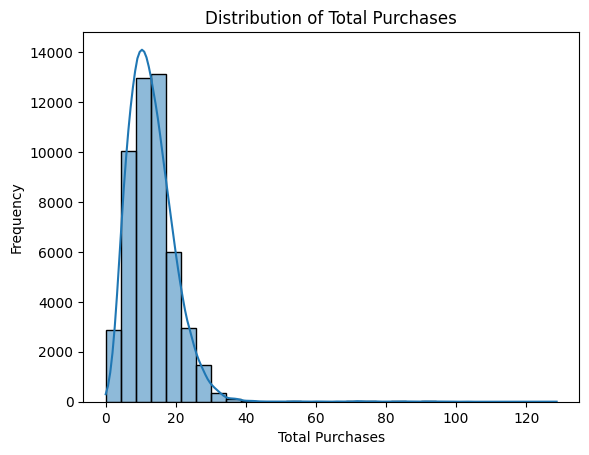

In [97]:
sns.histplot(df["Total_Purchases"], bins=30, kde=True)
plt.title("Distribution of Total Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

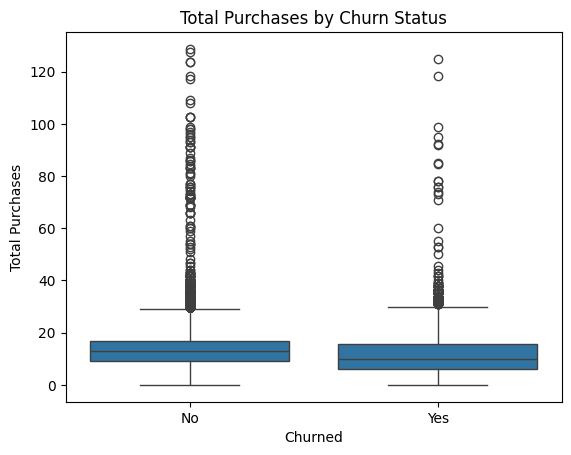

In [98]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Total_Purchases")
plt.title("Total Purchases by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Total Purchases")
plt.show()

แบบลองดู Boxplot แบบตัด Outlier ออก

(0.0, 40.0)

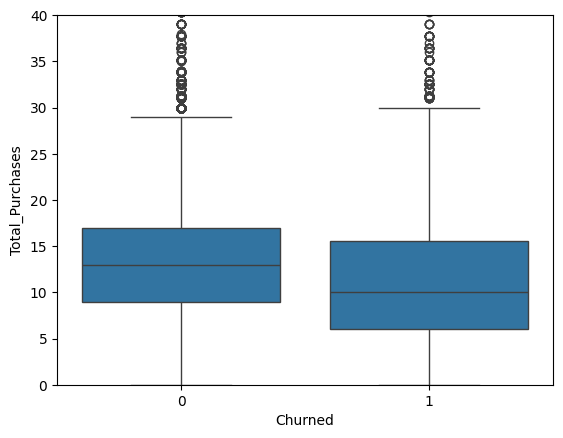

In [99]:
sns.boxplot(x="Churned", y="Total_Purchases", data=df)
plt.ylim(0,40)

<Axes: xlabel='Churned', ylabel='Total_Purchases'>

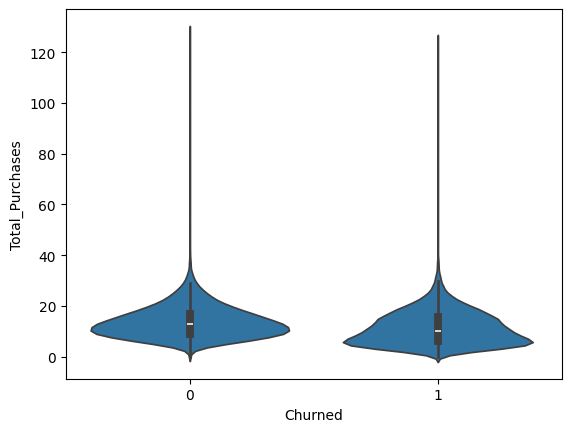

In [100]:
sns.violinplot(x="Churned", y="Total_Purchases", data=df)

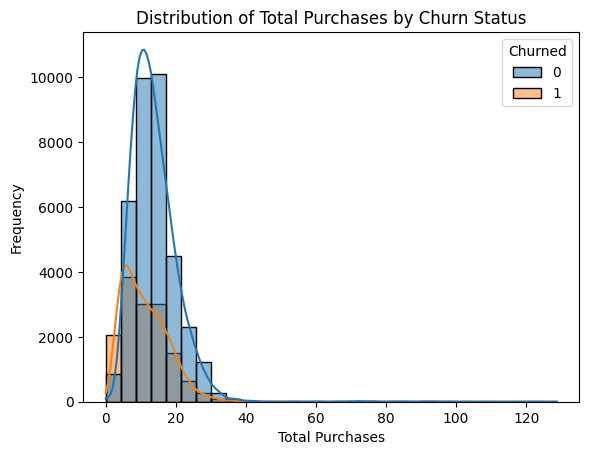

In [101]:
sns.histplot(data=df, x="Total_Purchases", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Total Purchases by Churn Status")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

In [102]:
from scipy import stats

churned = df[df["Churned"] == 1]["Total_Purchases"]
not_churned = df[df["Churned"] == 0]["Total_Purchases"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Total Purchases")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Total Purchases")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Total Purchases


A Mann-Whitney U test shows a statistically significant difference in total purchases between churned and retained users (p < 0.001). Although the distributions overlap visually, churn rate analysis reveals a clear pattern: customers with fewer purchases exhibit significantly higher churn rates. This suggests that purchase frequency is a meaningful indicator of customer retention.

In [103]:
Q1 = df["Total_Purchases"].quantile(0.25)
Q3 = df["Total_Purchases"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Total_Purchases"] < Q1 - 1.5 * IQR) | 
              (df["Total_Purchases"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 604 rows (1.21%)


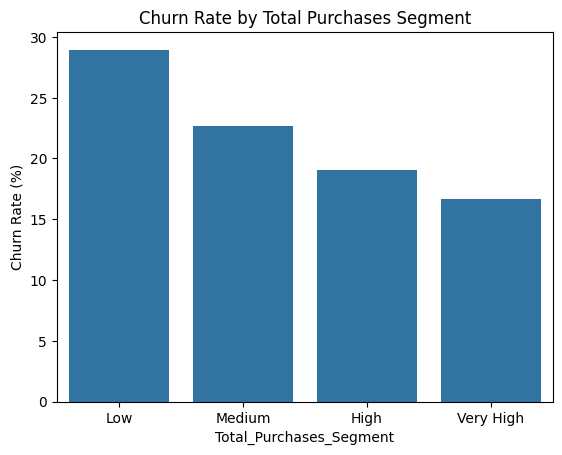

In [104]:
df["Total_Purchases_Segment"] = pd.cut(df["Total_Purchases"], 
                                       bins=4, 
                                       labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Total_Purchases_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Total Purchases Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

In [105]:
df.groupby("Churned")["Total_Purchases"].median()

Churned
0    13.0
1    10.0
Name: Total_Purchases, dtype: float64

### 2. Average_Order_Value

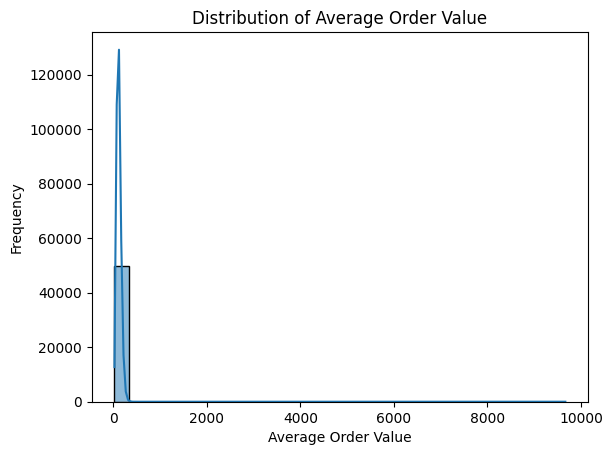

In [106]:
sns.histplot(df["Average_Order_Value"], bins=30, kde=True)
plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Frequency")
plt.show()

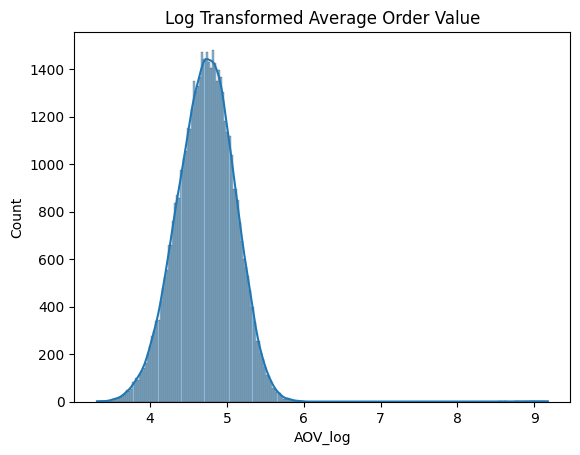

In [107]:
df["AOV_log"] = np.log1p(df["Average_Order_Value"])

sns.histplot(df["AOV_log"], kde=True)
plt.title("Log Transformed Average Order Value")
plt.show()

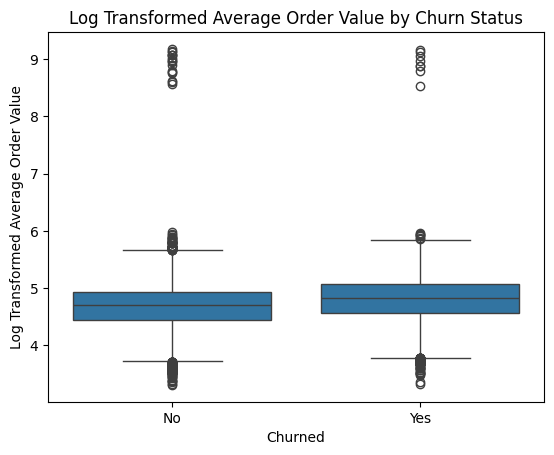

In [108]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="AOV_log")
plt.title("Log Transformed Average Order Value by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Log Transformed Average Order Value")
plt.show()

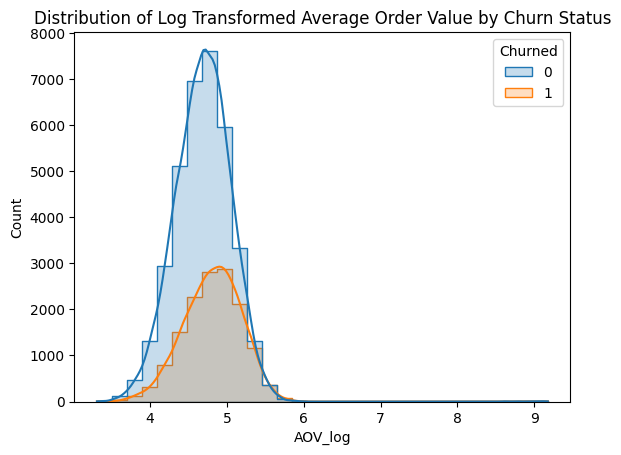

In [109]:
sns.histplot(
    data=df,
    x="AOV_log",
    hue="Churned",
    bins=30,
    element="step",
    kde=True
)

plt.title("Distribution of Log Transformed Average Order Value by Churn Status")
plt.show()

<Axes: xlabel='AOV_log', ylabel='Density'>

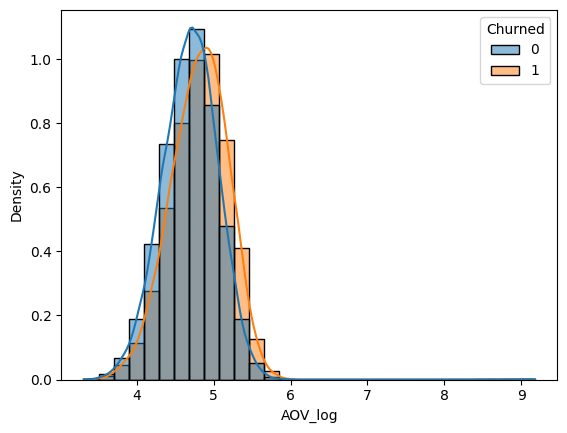

In [110]:
sns.histplot(
    data=df,
    x="AOV_log",
    hue="Churned",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

TIP FROM AI(ChatGPT)
็Histrogram
1. ตำแหน่งของยอด (peak)
2. การ overlap ของ distribution
3. การเลื่อนของเส้น

- distribution overlap
- เส้นสีน้ำเงิน = ไม่ churn
- เส้นสีส้ม = churn

เส้นสองเส้นซ้อนกันเยอะมาก แปลว่า ลูกค้าสองกลุ่มมีพฤติกรรมคล้ายกัน (แยก churn กับ non-churn ไม่ได้ชัด)

In [111]:
churned = df[df["Churned"] == 1]["AOV_log"]
not_churned = df[df["Churned"] == 0]["AOV_log"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญใน Log Transformed Average Order Value")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญใน Log Transformed Average Order Value")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญใน Log Transformed Average Order Value


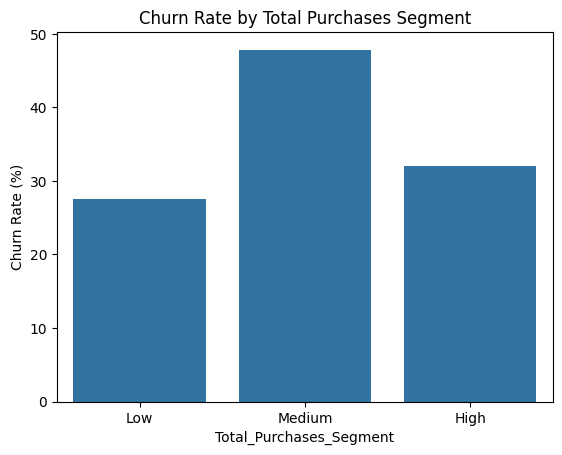

In [127]:
df["Total_Purchases_Segment"] = pd.cut(df["AOV_log"], 
                                       bins=3, 
                                       labels=["Low", "Medium", "High"])

churn_rate = df.groupby("Total_Purchases_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Total Purchases Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

In [112]:
print("We measured the median log transformed average order value for both churned and non-churned customers:")
df.groupby("Churned")["AOV_log"].median()

We measured the median log transformed average order value for both churned and non-churned customers:


Churned
0    4.699889
1    4.831469
Name: AOV_log, dtype: float64

คำถาม	metric
1. ลูกค้า churn ซื้อแพงกว่าไหม  >>	median
2. AOV ส่งผลต่อ churn ไหม   >>	churn rate
3. distribution เป็นยังไง    >>	 histogram

Customers who churn tend to have slightly higher Average Order Value compared to non-churned customers.
However, the distributions largely overlap, indicating that AOV alone is not a strong predictor of churn.

In [113]:
df["AOV_segment"] = pd.qcut(df["AOV_log"], 4)

df.groupby("AOV_segment")["Churned"].mean()

AOV_segment
(3.309, 4.478]    0.218623
(4.478, 4.736]    0.246181
(4.736, 4.98]     0.291807
(4.98, 9.177]     0.399424
Name: Churned, dtype: float64

AOV ยิ่งสูง → churn rate ยิ่งสูง แต่มีผมไม่มาไม่ไช้ใจความสําคัญ

### 3. Days_Since_Last_Purchase

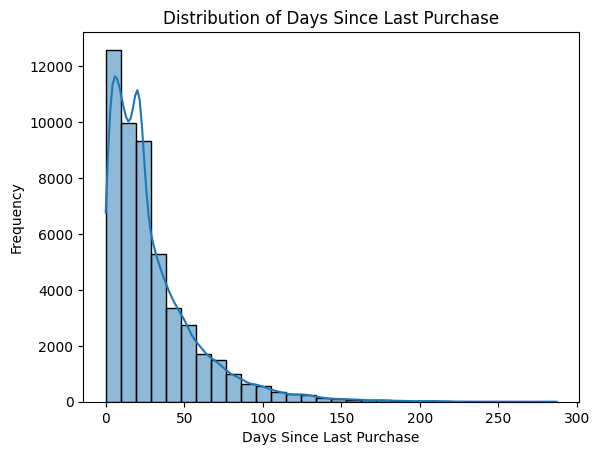

In [114]:
sns.histplot(df["Days_Since_Last_Purchase"], bins=30, kde=True)
plt.title("Distribution of Days Since Last Purchase")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Frequency")
plt.show()

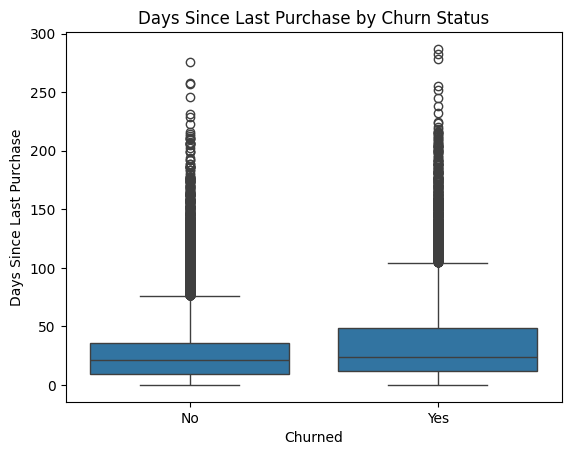

In [115]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Days_Since_Last_Purchase")
plt.title("Days Since Last Purchase by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Days Since Last Purchase")
plt.show()

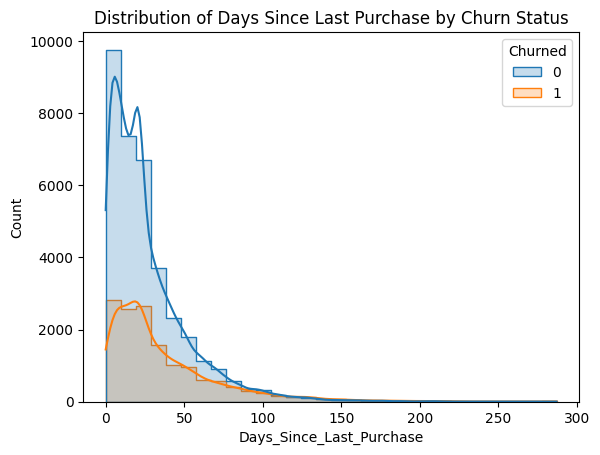

In [121]:
sns.histplot(
    data=df,
    x="Days_Since_Last_Purchase",
    hue="Churned",
    bins=30,
    element="step",
    kde=True
)

plt.title("Distribution of Days Since Last Purchase by Churn Status")
plt.show()

In [122]:
from scipy import stats

churned = df[df["Churned"] == 1]["Days_Since_Last_Purchase"]
not_churned = df[df["Churned"] == 0]["Days_Since_Last_Purchase"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Days Since Last Purchase")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Days Since Last Purchase")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Days Since Last Purchase


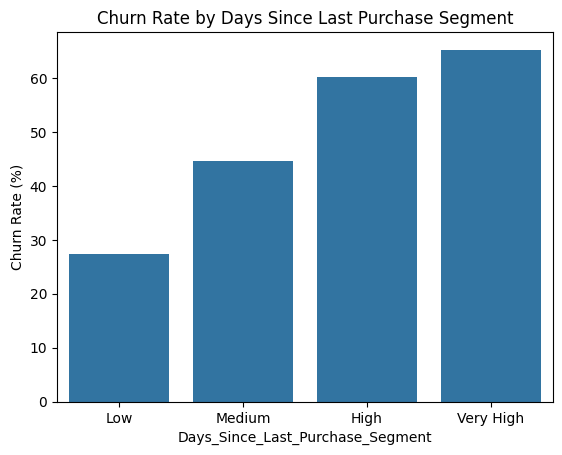

In [125]:
df["Days_Since_Last_Purchase_Segment"] = pd.cut(df["Days_Since_Last_Purchase"], 
                                                bins=4, 
                                                labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Days_Since_Last_Purchase_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Days Since Last Purchase Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### 4. Discount_Usage_Rate

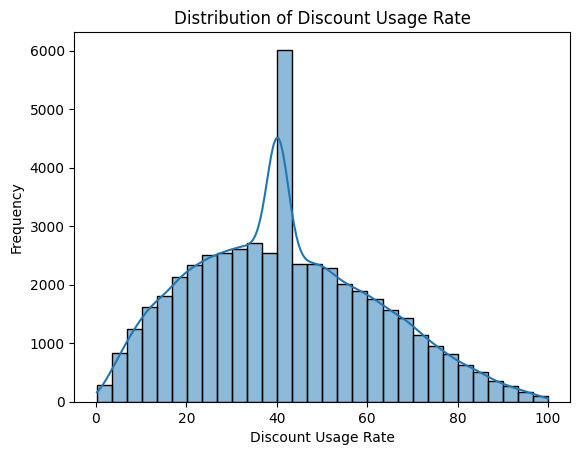

In [128]:
sns.histplot(df["Discount_Usage_Rate"], bins=30, kde=True)
plt.title("Distribution of Discount Usage Rate")
plt.xlabel("Discount Usage Rate")
plt.ylabel("Frequency")
plt.show()

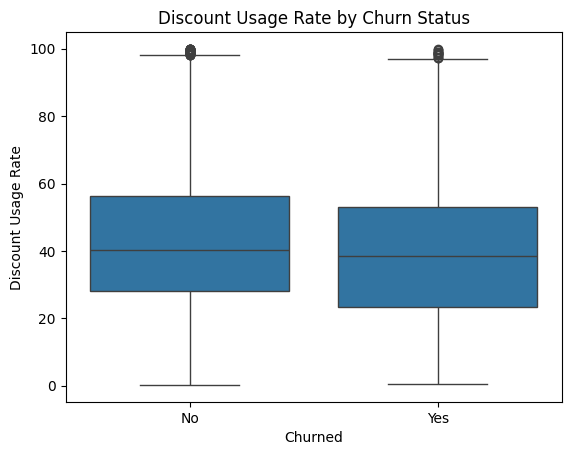

In [129]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Discount_Usage_Rate")
plt.title("Discount Usage Rate by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Discount Usage Rate")
plt.show()

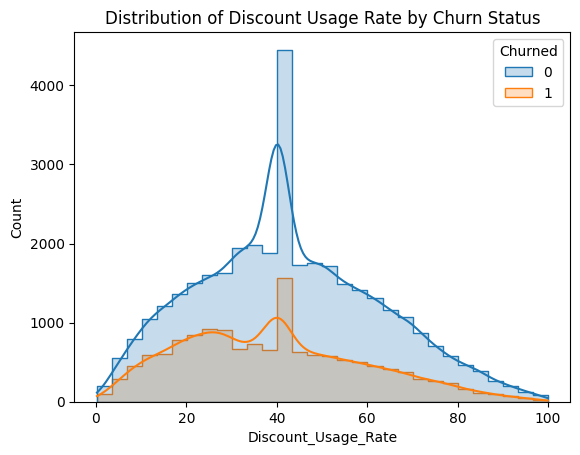

In [130]:
sns.histplot(
    data=df,
    x="Discount_Usage_Rate",
    hue="Churned",
    bins=30,
    element="step",
    kde=True
)

plt.title("Distribution of Discount Usage Rate by Churn Status")
plt.show()

In [131]:
from scipy import stats

churned = df[df["Churned"] == 1]["Discount_Usage_Rate"]
not_churned = df[df["Churned"] == 0]["Discount_Usage_Rate"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Discount Usage Rate")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Discount Usage Rate")

Mann-Whitney U Test: p-value = nan
ไม่มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Discount Usage Rate


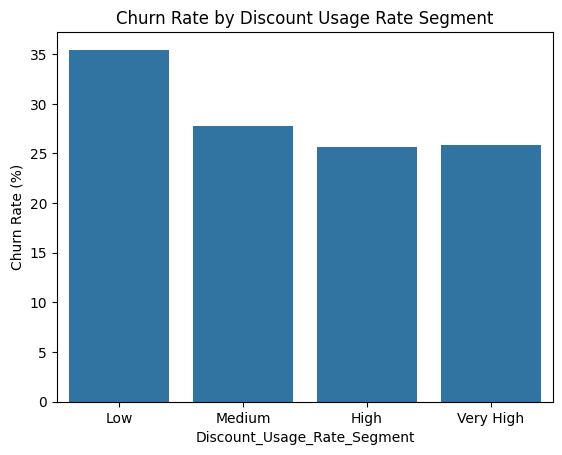

In [132]:
df["Discount_Usage_Rate_Segment"] = pd.cut(df["Discount_Usage_Rate"], 
                                           bins=4, 
                                           labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Discount_Usage_Rate_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Discount Usage Rate Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### Check Entire Feature on ChurnRate Effect

In [118]:
purchaseBehavior_features = [
    "Total_Purchases",
    "Average_Order_Value",
    "Returns_Rate",
    "Discount_Usage_Rate"
]

In [120]:
df[purchaseBehavior_features].corrwith(df["Churned"]).sort_values()

Total_Purchases       -0.160393
Discount_Usage_Rate   -0.075840
Average_Order_Value    0.042288
Returns_Rate           0.051122
dtype: float64

- Total_Purchases = -0.16 → weak relationship
- ตัวอื่น ๆ แทบไม่มีผล

Purchase behavior features
มีผลกับ churn ค่อนข้างน้อย

Purchase Behavior Analysis

Purchase-related features show relatively weak correlations with churn.
Among them, Total Purchases has the strongest relationship (-0.16), suggesting that customers who purchase more frequently are less likely to churn.
However, other purchase metrics such as Average Order Value and Discount Usage Rate exhibit minimal correlation with churn.



### Insight 
Compared to purchase behavior features, engagement metrics (e.g., session duration, pages per session) demonstrate stronger relationships with churn, indicating that customer engagement may be a more important factor in retention.

### Check Corrrleation between each other

In [133]:
df[["Total_Purchases","Discount_Usage_Rate","Average_Order_Value","Returns_Rate"]].corr()

,Total_Purchases,Discount_Usage_Rate,Average_Order_Value,Returns_Rate
Total_Purchases,1.000000,0.031721,0.003374,0.274133
Discount_Usage_Rate,0.031721,1.000000,-0.000210,-0.011216
Average_Order_Value,0.003374,-0.000210,1.000000,0.000363
Returns_Rate,0.274133,-0.011216,0.000363,1.000000


Total_Purchases ความสัมพันธ์อ่อน Returns_Rate

ที่เหลือ แทบไม่มีความสัมพันธ์